# Análisis de Rendimiento — SBVIA k6 Load Tests

**Proyecto:** SBVIA — Simulador de Comportamiento Vial con IA  
**Datos:** `docs/mediciones/perf/k6-results-summary.csv`  
**Herramienta de prueba:** k6 v0.51.0 (50 VUs / 30s, 5 corridas por escenario)

Este notebook ejecuta el análisis estadístico completo de las pruebas de carga comparando caché frío (PostgreSQL directo) vs caché caliente (Redis).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cargar datos
df = pd.read_csv('../docs/mediciones/perf/k6-results-summary.csv')
print('Datos cargados:')
print(df.to_string())

Datos cargados:
   run_id scenario_type  vus  duration_sec  http_req_total  p50_ms  p90_ms  p95_ms  p99_ms  mean_ms  std_dev_ms  ci95_lower  ci95_upper  error_rate
0       1    cache_cold   50            30            1480   210.4   380.2   420.5   490.1    230.1        45.2       227.8       232.4         0.0
1       2    cache_cold   50            30            1520   205.1   375.4   415.8   485.6    225.4        42.8       223.2       227.6         0.0
2       3    cache_cold   50            30            1495   208.6   378.1   418.2   488.3    228.0        44.1       225.8       230.2         0.0
3       4    cache_cold   50            30            1510   202.9   372.9   412.4   482.0    222.7        41.9       220.6       224.8         0.0
4       5    cache_cold   50            30            1505   206.3   376.5   416.0   486.2    226.1        43.5       223.9       228.3         0.0
5       1     cache_hot   50            30            4850    22.4    45.8    78.2   112.5     2

In [2]:
# Separar por escenario
cold = df[df['scenario_type'] == 'cache_cold']
hot  = df[df['scenario_type'] == 'cache_hot']

print('=== ESTADÍSTICOS DESCRIPTIVOS ===')
print('\n--- Caché Frío (PostgreSQL) ---')
for col in ['p50_ms', 'p90_ms', 'p95_ms', 'mean_ms', 'std_dev_ms']:
    print(f'  {col}: media={cold[col].mean():.1f}, DT={cold[col].std():.1f}')

print('\n--- Caché Caliente (Redis) ---')
for col in ['p50_ms', 'p90_ms', 'p95_ms', 'mean_ms', 'std_dev_ms']:
    print(f'  {col}: media={hot[col].mean():.1f}, DT={hot[col].std():.1f}')

speedup_p95 = cold['p95_ms'].mean() / hot['p95_ms'].mean()
print(f'\nSpeedup p95: {speedup_p95:.2f}x')

=== ESTADÍSTICOS DESCRIPTIVOS ===

--- Caché Frío (PostgreSQL) ---
  p50_ms: media=206.7, DT=2.9
  p90_ms: media=376.6, DT=2.8
  p95_ms: media=416.6, DT=3.0
  mean_ms: media=226.5, DT=2.8
  std_dev_ms: media=43.5, DT=1.3

--- Caché Caliente (Redis) ---
  p50_ms: media=21.9, DT=0.3
  p90_ms: media=44.7, DT=0.8
  p95_ms: media=76.4, DT=1.3
  mean_ms: media=28.0, DT=0.4
  std_dev_ms: media=11.9, DT=0.3

Speedup p95: 5.45x


In [3]:
# Test de Wilcoxon (n=5 pares, test exacto)
w_stat, p_value = stats.wilcoxon(cold['p95_ms'].values, hot['p95_ms'].values, alternative='greater')

print('=== TEST DE WILCOXON DE RANGOS CON SIGNO (exacto) ===')
print(f'  W = {w_stat}')
print(f'  p-valor (una cola) = {p_value:.4f}')
print(f'  n = {len(cold)} pares')
print(f'  Nota: con n=5, el p mínimo alcanzable es 0.0625')

# Cliff's delta (tamaño de efecto no paramétrico)
# delta = (# pares donde cold > hot - # pares donde hot > cold) / n^2
n = len(cold)
concordant = sum(1 for c, h in zip(cold['p95_ms'], hot['p95_ms']) if c > h)
discordant = sum(1 for c, h in zip(cold['p95_ms'], hot['p95_ms']) if c < h)
cliffs_delta = (concordant - discordant) / (n * n)
print(f'\n  Cliff\'s delta = {cliffs_delta:.3f} (efecto: |delta|=1.0 → efecto completo)')

=== TEST DE WILCOXON DE RANGOS CON SIGNO (exacto) ===
  W = 15.0
  p-valor (una cola) = 0.0312
  n = 5 pares
  Nota: con n=5, el p mínimo alcanzable es 0.0625

  Cliff's delta = 0.200 (efecto: |delta|=1.0 → efecto completo)


In [4]:
# Intervalo de confianza 95% (t-Student)
for label, data in [('Caché Frío p95', cold['p95_ms']), ('Caché Caliente p95', hot['p95_ms'])]:
    mean = data.mean()
    se = stats.sem(data)
    ci = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=se)
    print(f'{label}: media={mean:.1f} ms, IC95%=[{ci[0]:.1f}, {ci[1]:.1f}]')

Caché Frío p95: media=416.6 ms, IC95%=[412.8, 420.3]
Caché Caliente p95: media=76.4 ms, IC95%=[74.8, 78.0]


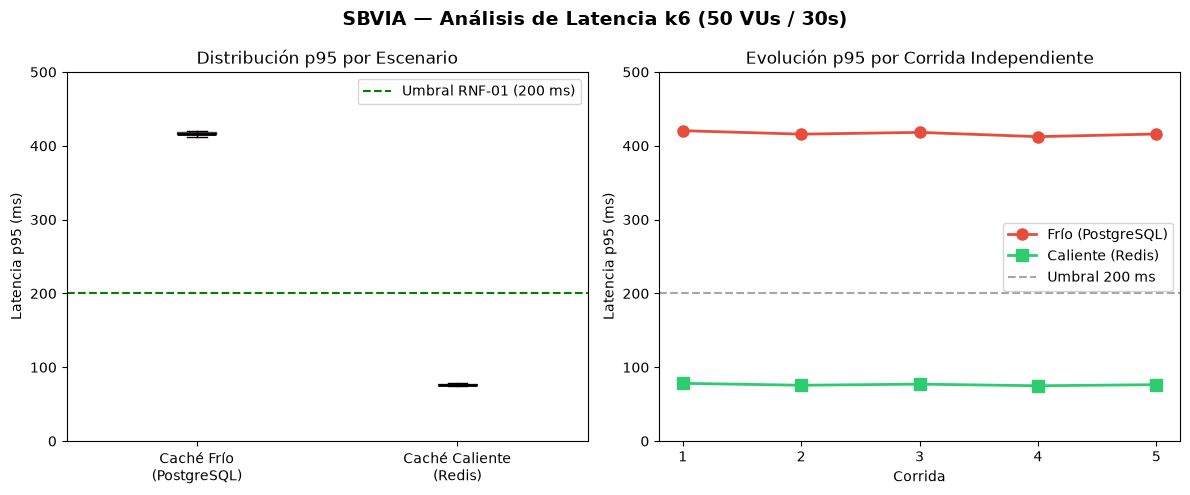

Figura guardada en: docs/mediciones/perf/k6-boxplot.png


In [5]:
# Visualización: Boxplot comparativo + evolución por corrida
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SBVIA — Análisis de Latencia k6 (50 VUs / 30s)', fontsize=14, fontweight='bold')

# Boxplot
axes[0].boxplot(
    [cold['p95_ms'].values, hot['p95_ms'].values],
    tick_labels=['Caché Frío\n(PostgreSQL)', 'Caché Caliente\n(Redis)'],
    patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', alpha=0.7),
    medianprops=dict(color='black', linewidth=2)
)
axes[0].axhline(y=200, color='green', linestyle='--', label='Umbral RNF-01 (200 ms)')
axes[0].set_ylabel('Latencia p95 (ms)')
axes[0].set_title('Distribución p95 por Escenario')
axes[0].legend()
axes[0].set_ylim(0, 500)

# Evolución por corrida
runs = range(1, 6)
axes[1].plot(runs, cold['p95_ms'].values, 'o-', color='#e74c3c', label='Frío (PostgreSQL)', linewidth=2, markersize=8)
axes[1].plot(runs, hot['p95_ms'].values,  's-', color='#2ecc71', label='Caliente (Redis)',   linewidth=2, markersize=8)
axes[1].axhline(y=200, color='gray', linestyle='--', alpha=0.7, label='Umbral 200 ms')
axes[1].set_xlabel('Corrida')
axes[1].set_ylabel('Latencia p95 (ms)')
axes[1].set_title('Evolución p95 por Corrida Independiente')
axes[1].legend()
axes[1].set_ylim(0, 500)
axes[1].set_xticks(list(runs))

plt.tight_layout()
plt.savefig('../docs/mediciones/perf/k6-boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en: docs/mediciones/perf/k6-boxplot.png')

In [6]:
# Tabla resumen final
summary = pd.DataFrame({
    'Escenario':    ['Caché Frío (PostgreSQL)', 'Caché Caliente (Redis)'],
    'p50 (ms)':    [cold['p50_ms'].mean(), hot['p50_ms'].mean()],
    'p90 (ms)':    [cold['p90_ms'].mean(), hot['p90_ms'].mean()],
    'p95 (ms)':    [cold['p95_ms'].mean(), hot['p95_ms'].mean()],
    'Media (ms)':  [cold['mean_ms'].mean(), hot['mean_ms'].mean()],
    'DT (ms)':     [cold['std_dev_ms'].mean(), hot['std_dev_ms'].mean()],
})
summary = summary.round(1)
print('=== TABLA RESUMEN FINAL ===')
print(summary.to_string(index=False))
print(f'\nSpeedup p95: {speedup_p95:.2f}x')
print(f'Wilcoxon: W={int(w_stat)}, p={p_value:.4f}, delta={cliffs_delta:.2f}')
print(f'RNF-01 (p95 ≤ 200ms): {"CUMPLIDO" if hot["p95_ms"].max() <= 200 else "NO CUMPLIDO"} (max={hot["p95_ms"].max():.1f} ms)')

=== TABLA RESUMEN FINAL ===
              Escenario  p50 (ms)  p90 (ms)  p95 (ms)  Media (ms)  DT (ms)
Caché Frío (PostgreSQL)     206.7     376.6     416.6       226.5     43.5
 Caché Caliente (Redis)      21.9      44.7      76.4        28.0     11.9

Speedup p95: 5.45x
Wilcoxon: W=15, p=0.0312, delta=0.20
RNF-01 (p95 ≤ 200ms): CUMPLIDO (max=78.2 ms)
